In [1]:
# Plot baseline mortality for years 2000, 2010 and 2020

In [2]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from utils.utils import autosize_figure, land_filter

In [3]:
# === Path config ===
BMR_DIR = "/glade/work/awells/air_quality/BMR/"
POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/"

In [4]:
# === Health variables ===
# COPD (chronic obstructive pulonary disease)
# LRI (lower respiratory infection)
# IHD (ischemic heart disease)
# DM2 (type 2 diabetes)
# LC (tracheal, bronchus, and lung cancer)
# Stroke
health_vars = ["COPD", "LRI", "IHD", "DM2", "LC", "Stroke"]

In [5]:
def plot_mortality(da):
    # Create figure
    fig = plt.figure(figsize=autosize_figure(1, 1))
    gs = GridSpec(2, 1, height_ratios=[15, 1])  # rows, columns

    projection = ccrs.Robinson()
    crs = ccrs.PlateCarree()

    country_borders = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='50m',
        facecolor='none')

    # Compute discrete levels
    levels = MaxNLocator(nbins=8).tick_values(da.min(), da.max())
    cmap = plt.get_cmap('viridis')  # or any other colormap you prefer
    norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

    # First panel
    ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
    cb = da.plot(
        transform=crs,
        add_colorbar=False,
        cmap=cmap,
        norm=norm,
        subplot_kws={'projection': projection}
    )
    ax.coastlines(resolution="50m", linewidth=0.75)
    ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
    plt.title(f"{health_VAR} Mortality in {year}", fontsize=16)

    # First colorbar
    cax = fig.add_subplot(gs[1, 0])
    col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal',
                           boundaries=levels, ticks=levels)
    col_bar.set_label(f"Mortality due to {health_VAR}", fontsize=13)

    plt.tight_layout()

    out_file = f"Mortality_mean_{health_VAR}_{year}.png"
    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path)
    return

In [6]:
def create_global_country_map(da):
    # Path config
    MASKS_DIR = "/glade/work/awells/air_quality/BMR/masks/country/"

    # Load in country mask
    mask_file = "GBD_Country_Masks_0.10.nc"
    mask_path = os.path.join(MASKS_DIR, mask_file)
    masks = xr.open_dataarray(mask_path)

    # Create DataArray filled with NaNs
    global_array = xr.DataArray(
        np.full((len(masks.lat), len(masks.lon)), np.nan),
        coords={"lat": masks.lat.values, "lon": masks.lon.values},
        dims=["lat", "lon"]
    )

    # Loop over countries, select the data for each country and apply to
    # empty array using the country mask
    for i in range(len(masks.country)):
        mask = masks.isel(country=i)
        country = masks.isel(country=i)["country"]
        mortality_country = da.sel(country=country)
        global_array = global_array.where(mask == 0, mortality_country)

    return global_array

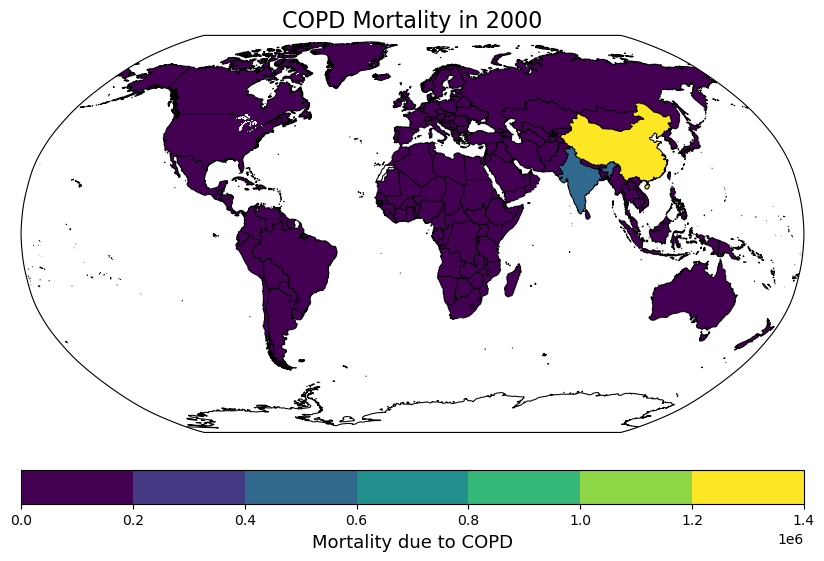

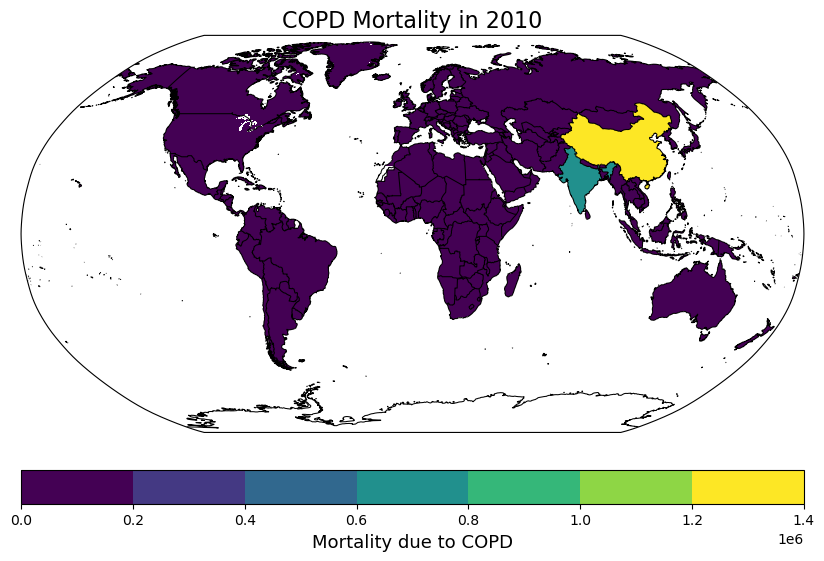

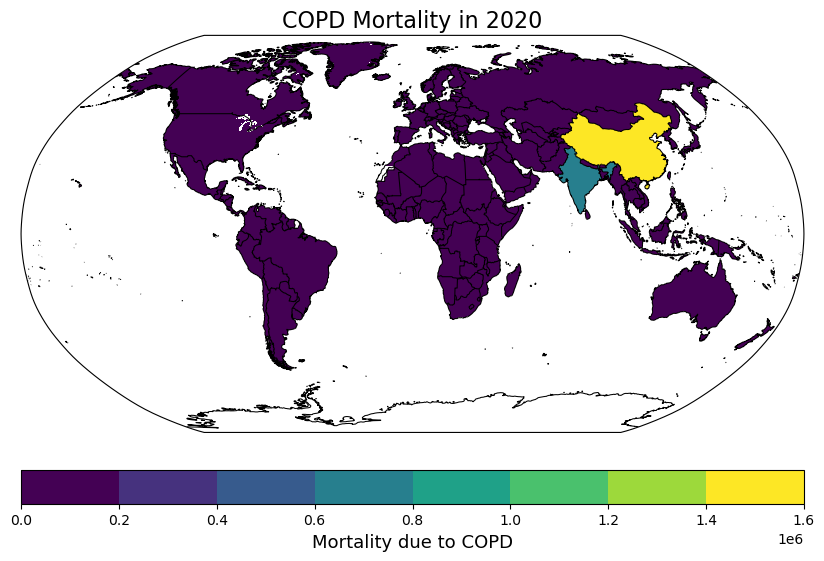

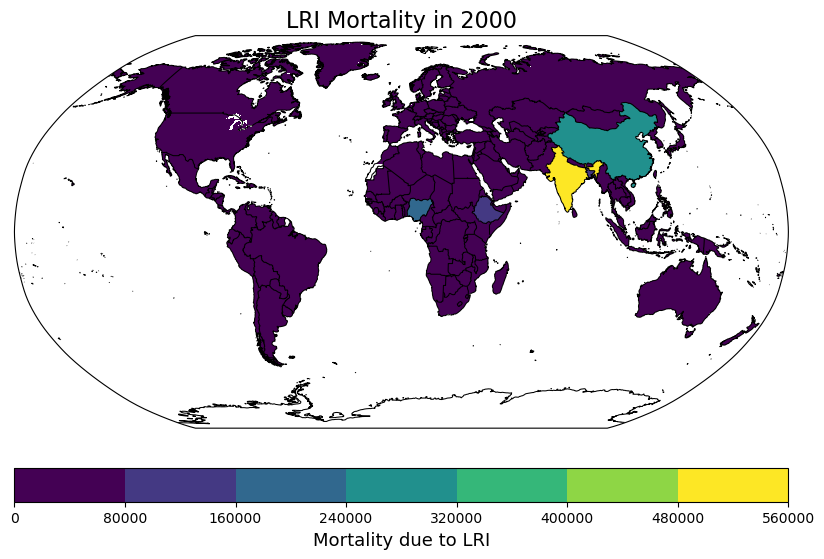

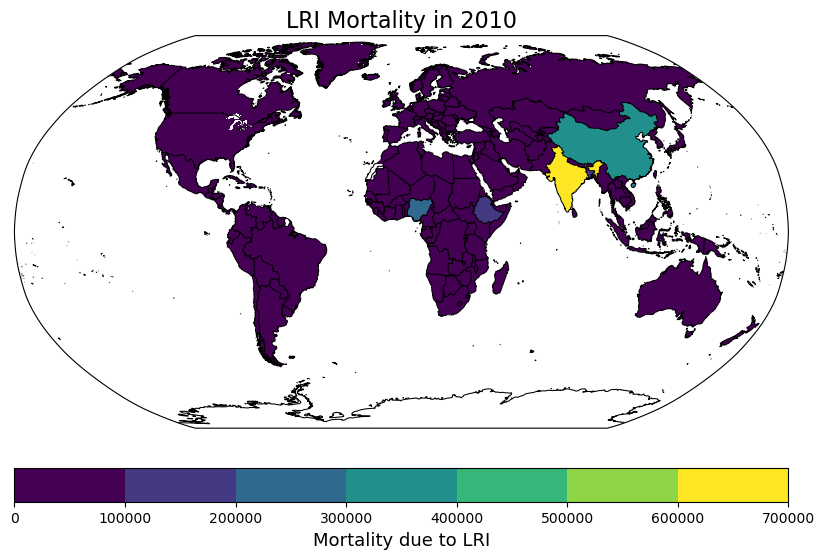

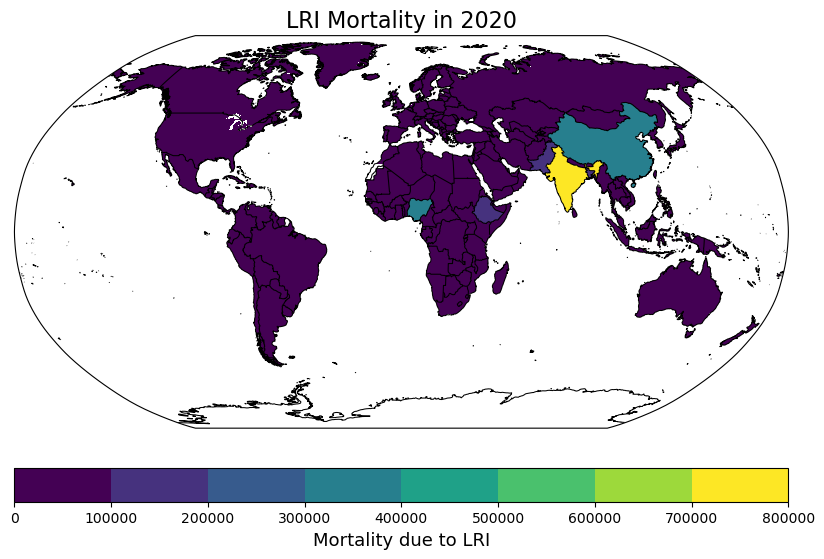

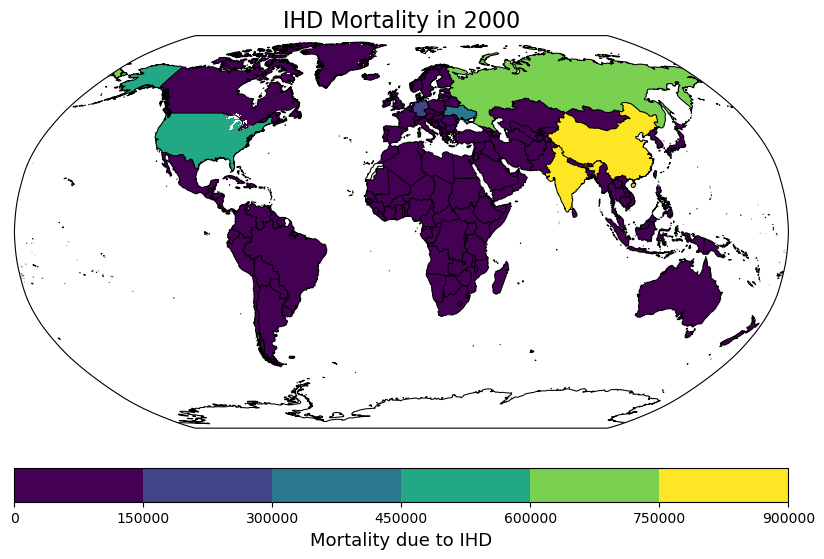

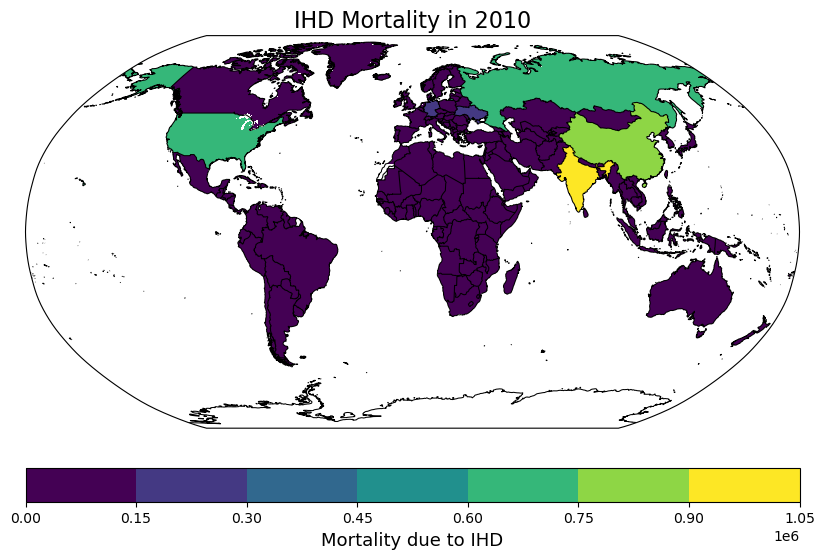

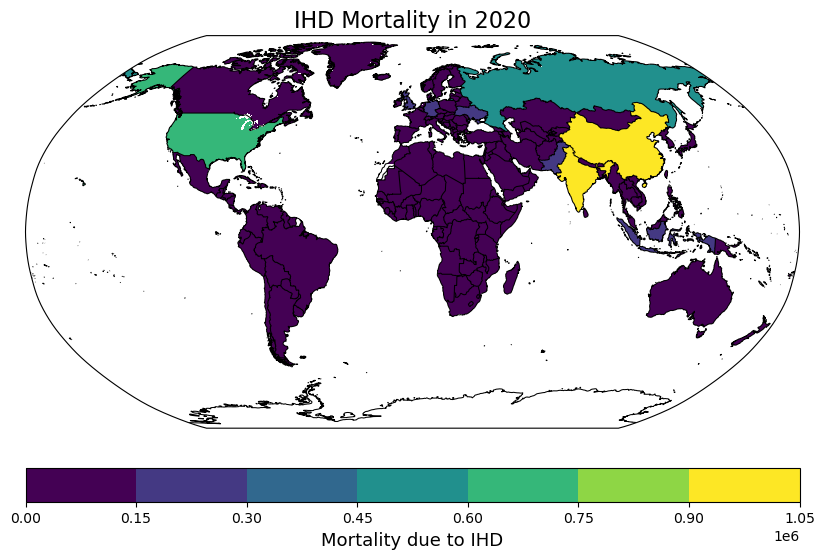

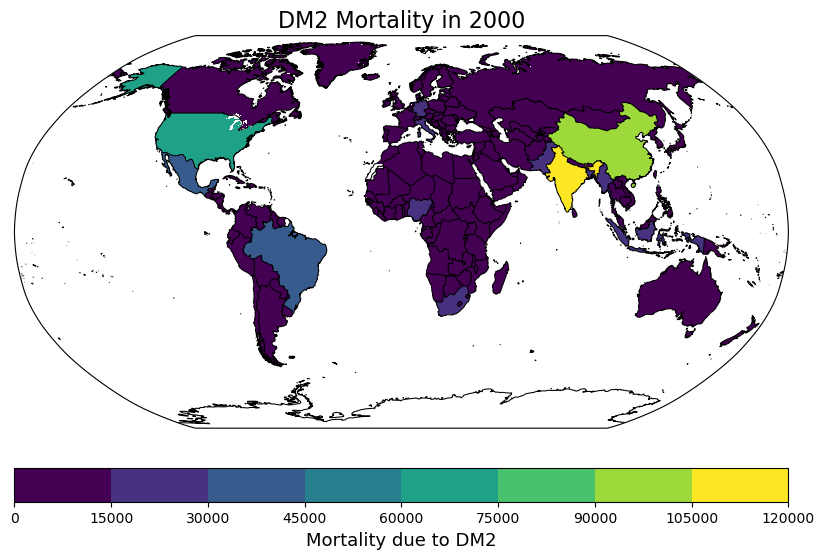

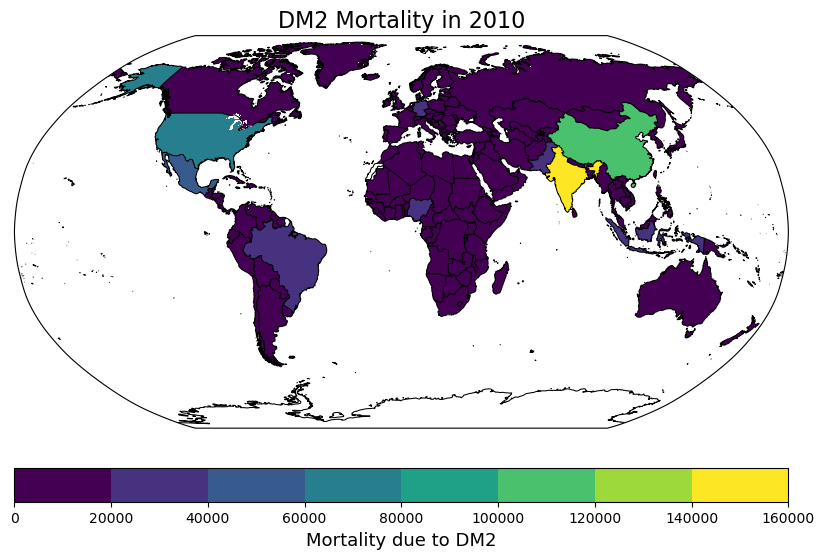

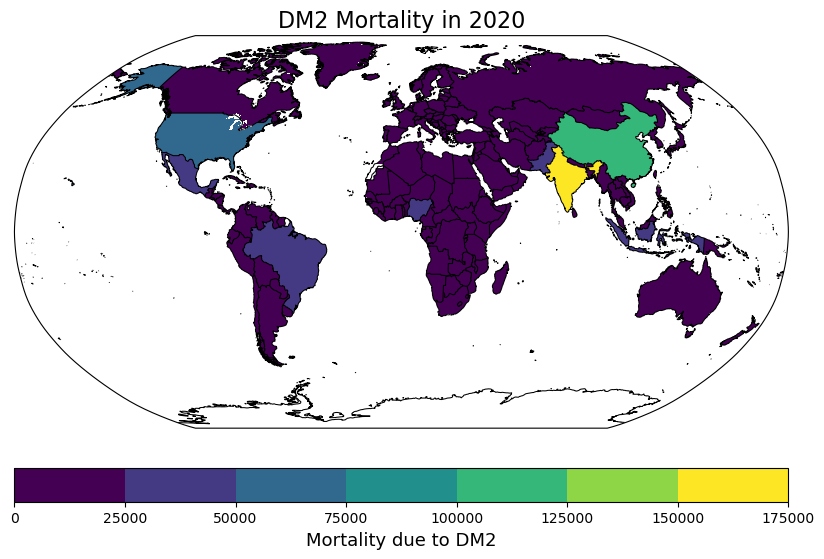

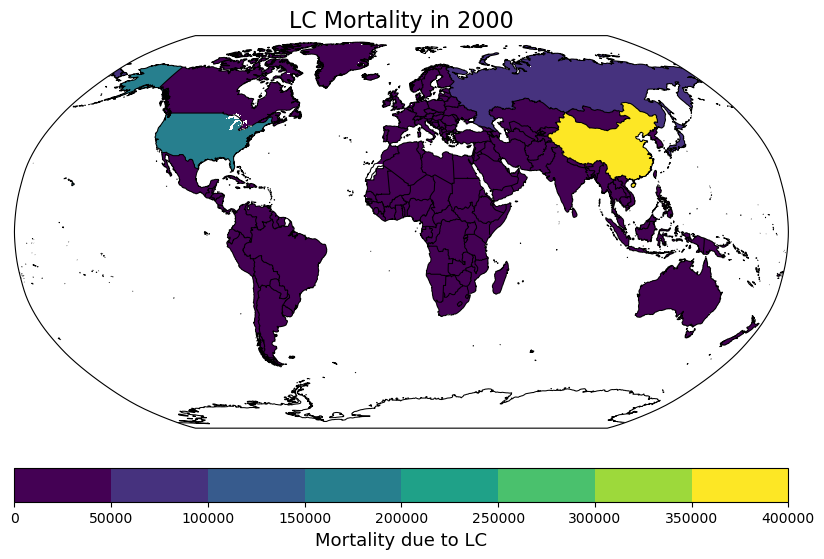

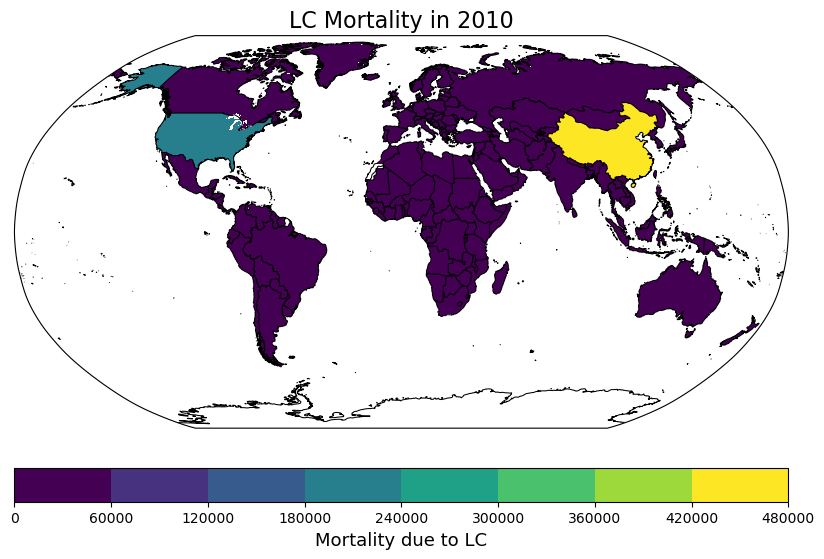

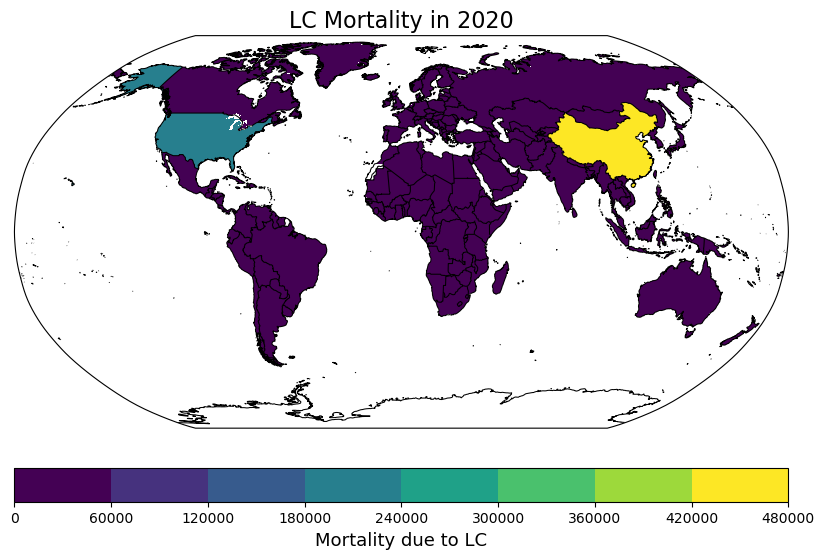

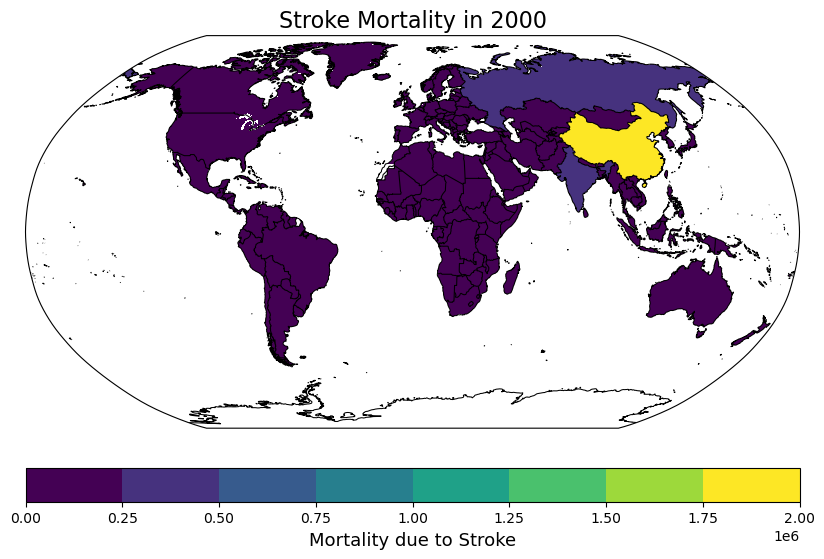

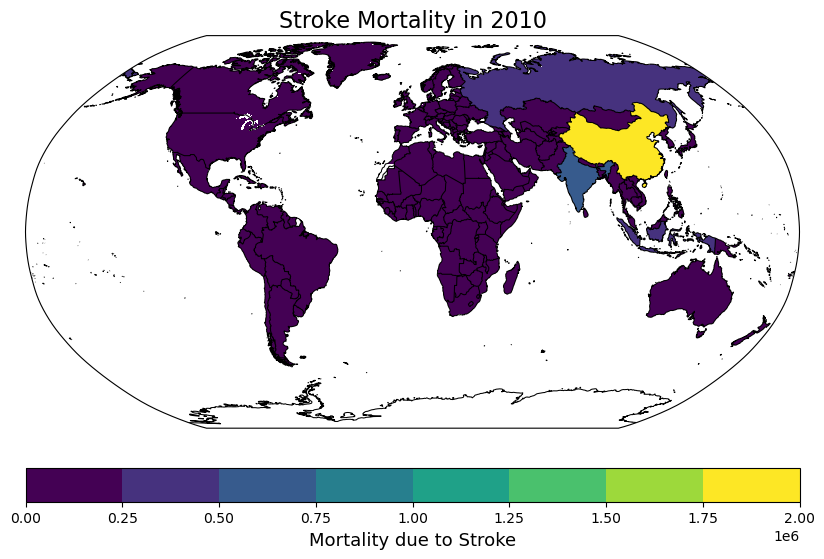

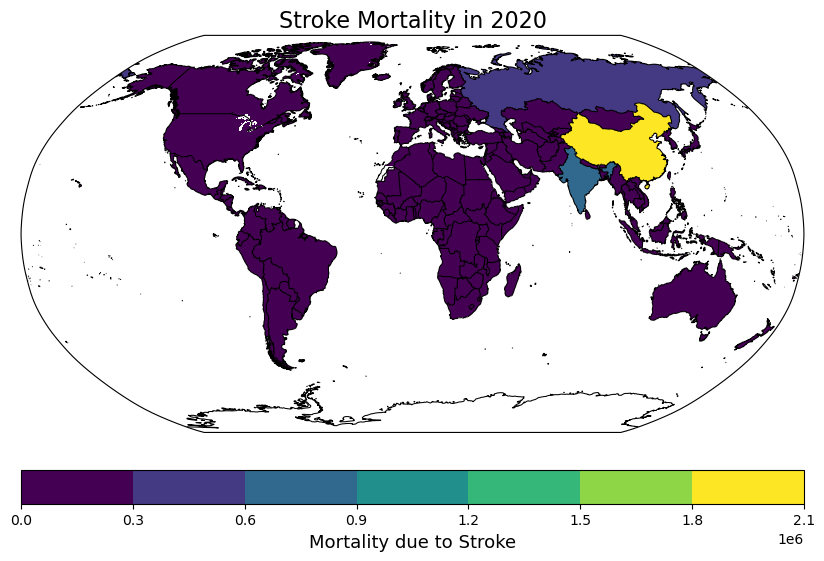

In [7]:
# === Main loop ===

for health_VAR in health_vars:
    for year in [2000, 2010, 2020]:
        bmr_file = f"GBD_BMR_Country_{health_VAR}_newlabels_1990-2009.nc"
        bmr_path = os.path.join(BMR_DIR, bmr_file)
        bmr = xr.open_dataarray(bmr_path)

        # Select mean value of bmr
        bmr_mean = bmr.sel(quantile="mean")

        pop_file = "ssp2_country_level_2000-2100.nc"
        pop_path = os.path.join(POP_DIR, pop_file)
        pop = xr.open_dataarray(pop_path)

        # Select year for population
        pop_year = pop.sel(year=year)

        mortality = (bmr_mean/100000) * pop_year

        global_map_mortality = create_global_country_map(mortality)

        plot_mortality(land_filter(global_map_mortality))